# estimate the impact of c350, c420, c450

In [1]:
import os
import numpy as np
from astropy.table import Table

from noah2 import data as D
from noah2 import util as U

from causalflow import causalflow
from causalflow import support as Support

In [2]:
import torch

In [3]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False
%matplotlib inline

In [4]:
cuda = torch.cuda.is_available()
device = ("cuda:0" if cuda else "cpu")

In [5]:
data_binary = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/data_binary_act.hdf5')
YX = np.array([np.array(data_binary[col]) for col in data_binary.colnames[:-3]]).T

# metro

In [6]:
_, iuniq = np.unique(data_binary[data_binary['arch'] == 'metro']['zipcode'], return_index=True)

In [7]:
q0, q1 = np.quantile(YX[data_binary['arch'] == 'metro'][iuniq], [0.5, 0.84], axis=0)
X_fid = q0

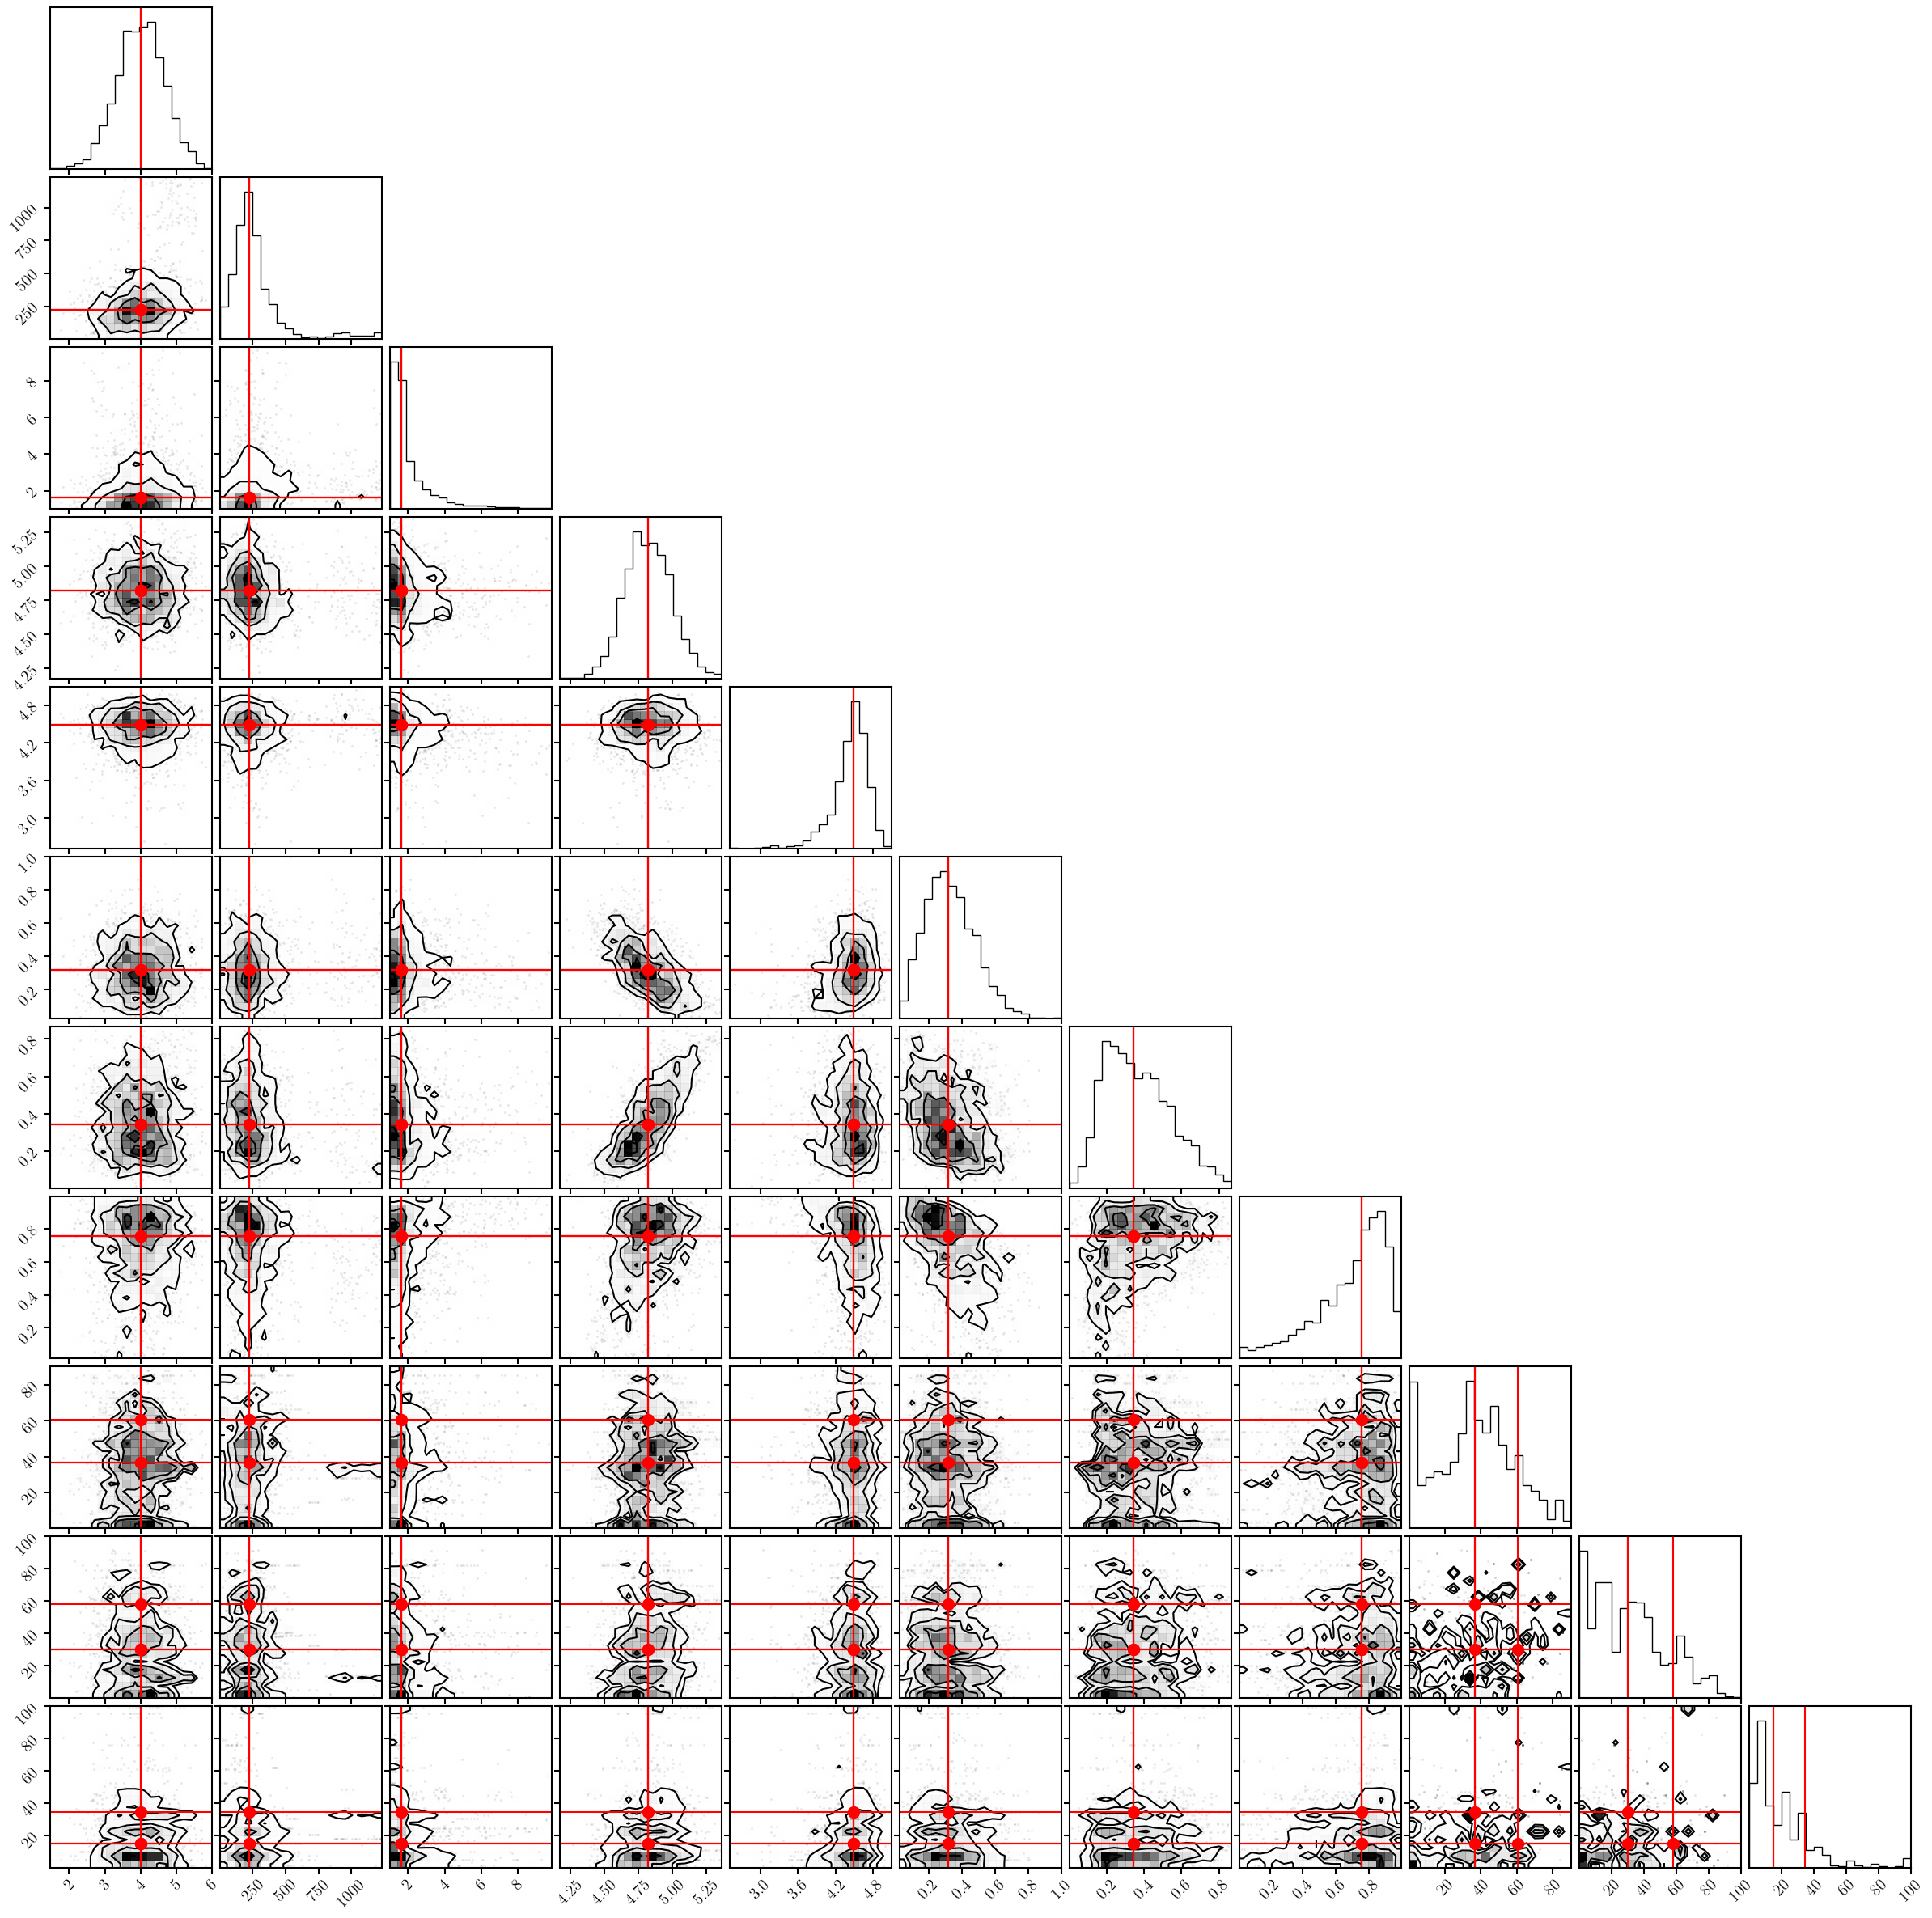

In [8]:
fig = DFM.corner(YX[data_binary['arch'] == 'metro'][iuniq])
DFM.overplot_lines(fig, X_fid, color='r')
for i in range(1,4): 
    _dT = np.zeros(len(X_fid))
    _dT[-i] = (q1 - q0)[-i]
    DFM.overplot_points(fig, [X_fid+_dT], color='r', markersize=20)
    DFM.overplot_lines(fig, X_fid+_dT, color='r')

In [11]:
arch = 'metro'
for i, act in zip([-3, -2, -1], ['c350', 'c420', 'c450']):
    print('--- %s ---' % act)
    
    cates = []
    for base in [0, 9, 64, 66]:  
        # load support for base sample
        Supp = Support.Support()
        Supp.load_optuna('support.%s.%i' % (arch, base), '/scratch/gpfs/chhahn/noah/noah2/qphi/', verbose=False)

        Cflow = causalflow.CausalFlowC(device=device)
        Cflow.load_support(Supp)    # load support

        # load flows
        Cflow.load_flows_optuna('%s.%i' % (arch, base), '/scratch/gpfs/chhahn/noah/noah2/qphi/', verbose=False)
    
        # check support before evaluating CATE
        XT_fid = np.concatenate([X_fid[1:-3], X_fid[-3:]])
        dT = np.zeros(3)        
        dT[i] = (q1 - q0)[i]
        XT_dfid = np.concatenate([X_fid[1:-3], X_fid[-3:] + dT])        

        # check support before evaluating CATE
        supported0 = Cflow.support.check_support(XT_fid, Nsample=10000, threshold=0.5)
        supported1 = Cflow.support.check_support(XT_dfid, Nsample=10000, threshold=0.5)
        if not supported0 or not supported1: 
            print('out of support')
            continue
        
        _cates = [] 
        for _ in range(10): 
            cate = Cflow.CATE(X_fid[1:-3], X_fid[-3:], dT, transf=lambda x: 10**x, support_threshold=0.5)
            _cates.append(cate)
        print('   %i, %.2f \pm %.2f' % (base, np.mean(_cates), np.std(_cates)))
        cates.append(np.array(_cates))
        
    print('%.2f \pm %.2f' % (np.mean(cates), np.std(cates)))
    print()

--- c350 ---
   0, 1057.31 \pm 485.00
   ---
   9, -9740.30 \pm 188.03
   ---
out of support
   ---
   66, 1619.42 \pm 144.12
   ---
-2354.52 \pm 5236.85

--- c420 ---
   0, -2803.56 \pm 413.29
   ---
   9, 1162.57 \pm 316.31
   ---
out of support
   ---
   66, -1860.22 \pm 320.56
   ---
-1167.07 \pm 1728.14

--- c450 ---
   0, -4829.15 \pm 386.50
   ---
   9, -6544.85 \pm 251.18
   ---
   64, -8731.15 \pm 515.32
   ---
   66, -2043.78 \pm 302.09
   ---
-5537.23 \pm 2474.44



# micro

In [72]:
_, iuniq = np.unique(data_binary[data_binary['arch'] == 'micro']['zipcode'], return_index=True)

In [73]:
q0, q1 = np.quantile(YX[data_binary['arch'] == 'micro'][iuniq], [0.5, 0.84], axis=0)
X_fid = q0

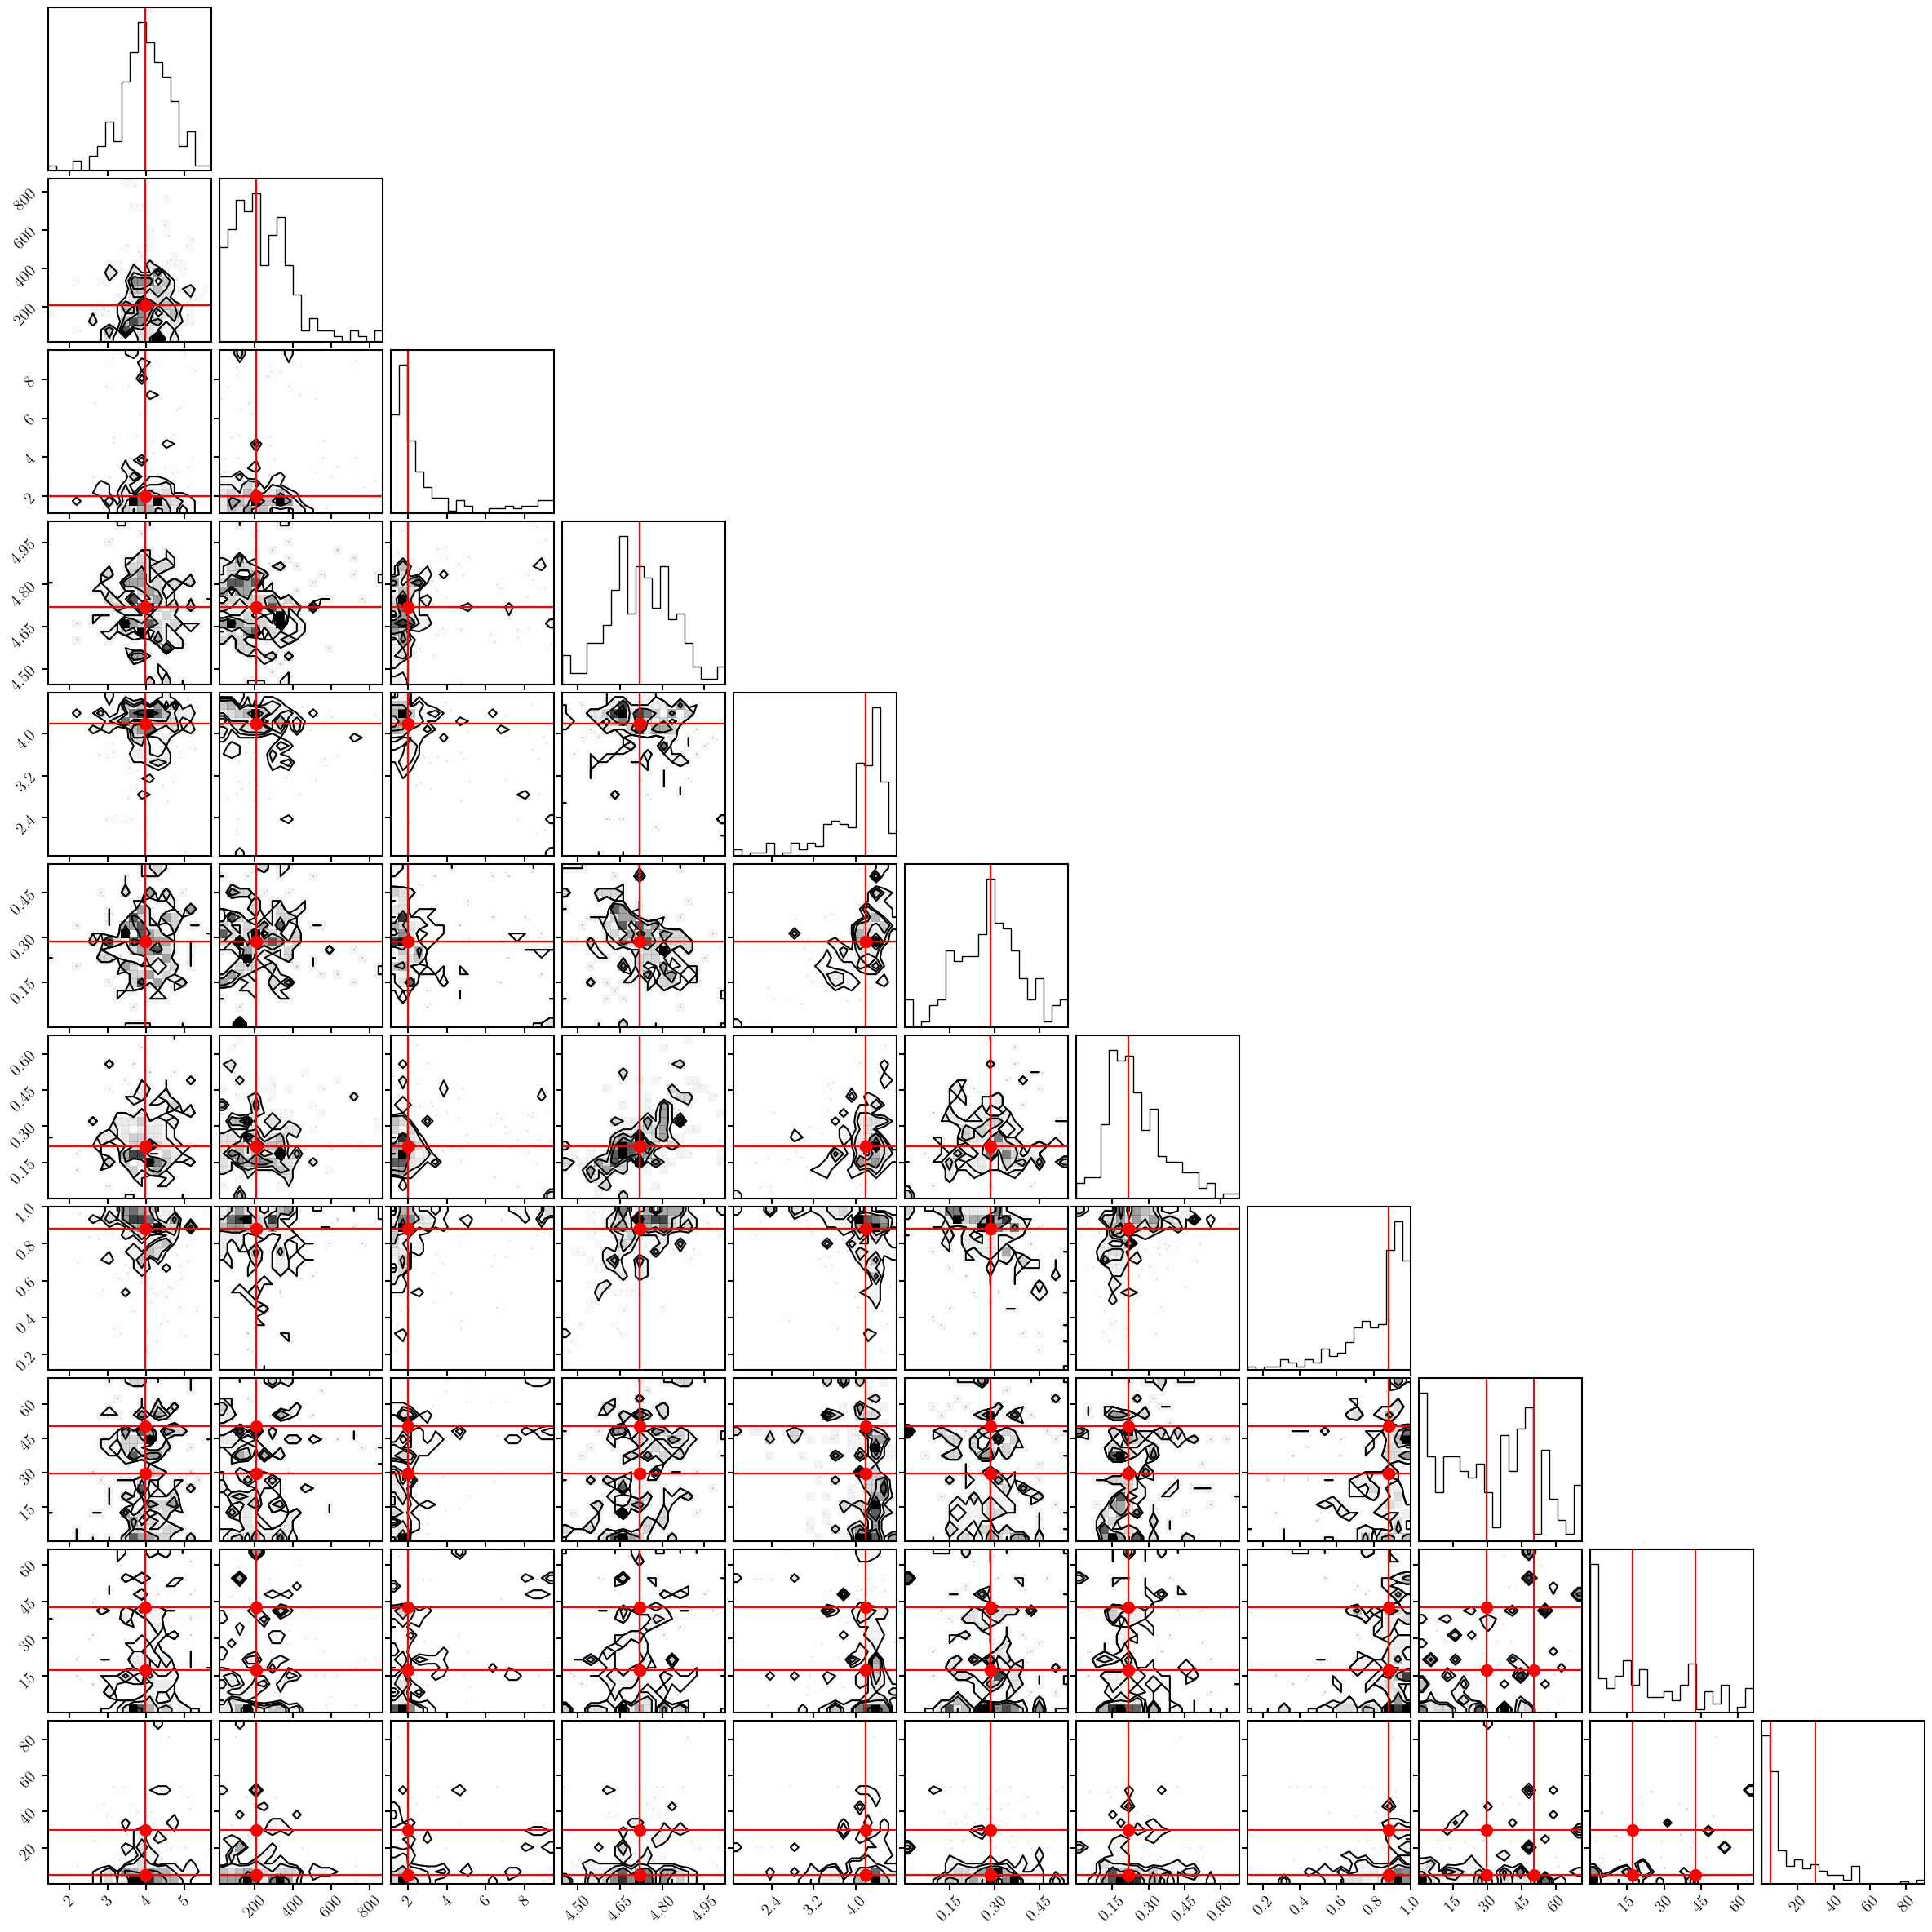

In [74]:
fig = DFM.corner(YX[data_binary['arch'] == 'micro'][iuniq])
DFM.overplot_lines(fig, X_fid, color='r')
for i in range(1,4): 
    _dT = np.zeros(len(X_fid))
    _dT[-i] = (q1 - q0)[-i]
    DFM.overplot_points(fig, [X_fid+_dT], color='r', markersize=20)
    DFM.overplot_lines(fig, X_fid+_dT, color='r')

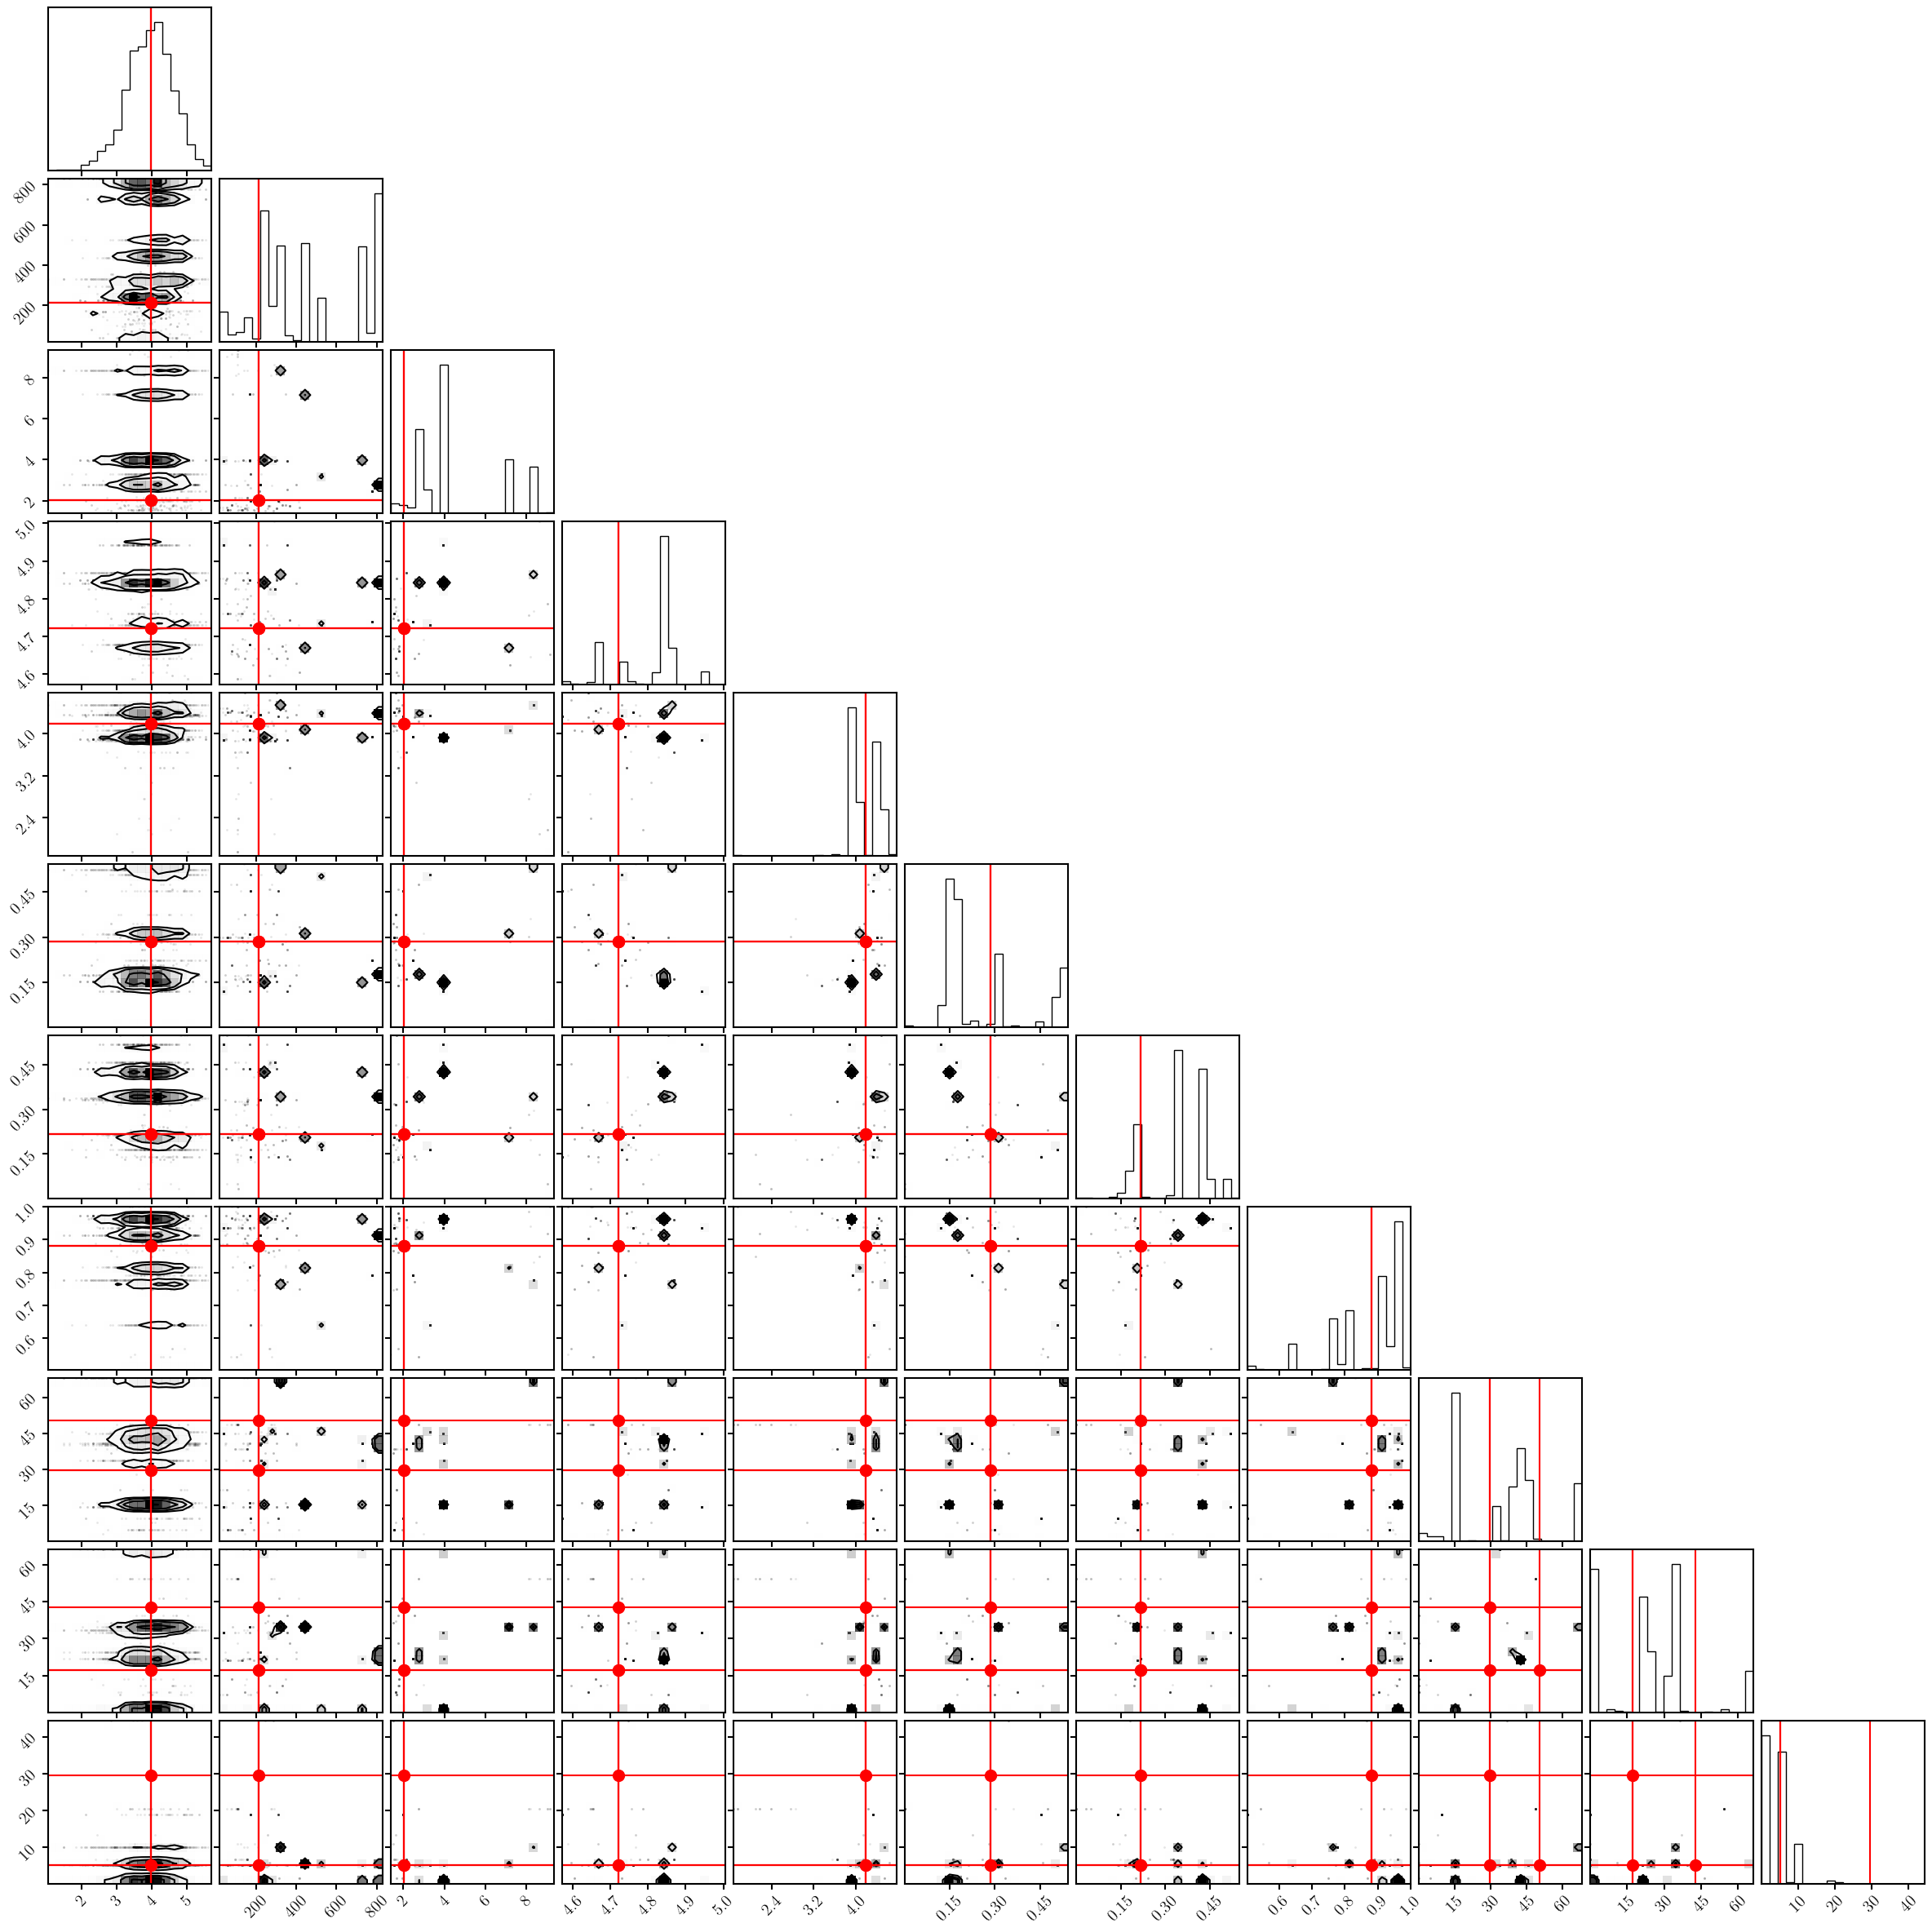

In [75]:
fig = DFM.corner(YX[(data_binary['arch'] == 'micro') & (data_binary['binary_code'] == 0)])
DFM.overplot_lines(fig, X_fid, color='r')
for i in range(1,4): 
    _dT = np.zeros(len(X_fid))
    _dT[-i] = (q1 - q0)[-i]
    DFM.overplot_points(fig, [X_fid+_dT], color='r', markersize=20)
    DFM.overplot_lines(fig, X_fid+_dT, color='r')

In [80]:
arch = 'micro'
for i, act in zip([-3, -2, -1], ['c350', 'c420', 'c450']):
    print('--- %s ---' % act)
    base = 0

    # load support for base sample
    Supp = Support.Support()
    Supp.load_optuna('support.%s.%i' % (arch, base), '/scratch/gpfs/chhahn/noah/noah2/qphi/', verbose=False)

    Cflow = causalflow.CausalFlowC(device=device)
    Cflow.load_support(Supp)    # load support

    # load flows
    Cflow.load_flows_optuna('%s.%i' % (arch, base), '/scratch/gpfs/chhahn/noah/noah2/qphi/', verbose=False)

    # check support before evaluating CATE
    XT_fid = np.concatenate([X_fid[1:-3], X_fid[-3:]])
    dT = np.zeros(3)        
    dT[i] = (q1 - q0)[i]
    XT_dfid = np.concatenate([X_fid[1:-3], X_fid[-3:] + dT])        

    # check support before evaluating CATE
    supported0 = Cflow.support.check_support(XT_fid, Nsample=10000, threshold=0.5)
    supported1 = Cflow.support.check_support(XT_dfid, Nsample=10000, threshold=0.5)
    if not supported0 or not supported1: 
        print('out of support')
        continue
        
    cates = []
    for i in range(100): 
        cate = Cflow.CATE(X_fid[1:-3], X_fid[-3:], dT, transf=lambda x: 10**x, support_threshold=0.5)
        cates.append(cate)
    print('%.2f \pm %.2f' % (np.mean(cates), np.std(cates)))
    print()

--- c350 ---
out of support
--- c420 ---
out of support
--- c450 ---
1004.23 \pm 635.61

